## Código guía para análisis del equipo

Este código se elaboró bajo las siguientes premisas:

1. La fuente de información primaria es la evaluación Aristas 2022 del INEEd, elaborada en función de tres formularios:
    - Aspectos de contexto
    - Aspectos socioemocionales
    - Prueba de suficiencia matemática

2. De dicho dataset se toman como variables predictoras básicas de segmentación a:
    - Ascendencia racial
    - Género del alumno
    - Zona del país (Montevideo o Interior)
    - Región del país (este, oeste, norte, sur y centro)
    - Categoría del centro eductativo al cual pertenece el alumno (Secundaria pública, Secundaria privada, UTU (escuela técnica))
    - Categoría del grupo al cual pertenece el alumno (Secundaria pública, Secundaria privada, UTU-CBT (escuelas técnicas con ciclo básico tecnológico), UTU-FPB (escuelas técnicas con formación profesional básica))

3. Además se incorporan como variables predictoras todo el conjunto de índices elaborados por Arista 2022, los cuales cubren diferentes dimensiones de análisis del fenómeno. En una versión inicial se consideran los índices numéricos y también la categorización del índice por quintiles si figura en el dataset original del INEEd. Queda para una segunda instancia definir si solo se consideran los índices numéricos o solo los categóricos, es decir evitar incorporar ambos a la vez para evitar redundancia de información.

4. La variable de salida se construye binarizando la columna del dataset original "Niveles_MAT", mapeando como rendimiento "Satisfactorio" (1) a los niveles N4 o N5, e "Insatisfactorio" (0) al resto de los niveles.

5. Se eliminan del dataset todos los registros correspondientes a estudiantes que no realizaron la prueba de evaluación matemática porque la variable de salida está relacionada con los resultados de dicha prueba (supuesto crítico para la aplicación de modelos supervisados). No se eliminan registros correspondientes a estudiantes que dejaron sin completar el formulario de contexto y/o socioeconómico (para reducir la pérdida de información y trabajar con la mayor cantidad posible de registros sin introducir sesgos por eliminación de datos). Los códigos 98 y 99 que se usan para denotar "No sabe o no contesta" fueron convertidos a NaN (vacíos). En el pipeline se tratan los NaN imputando las variables numéricas con KNNImputer() y las variables categóricas por la moda.

6. Se entrenan cuatro modelos distintos:
    - Regresión Logística
    - KNN
    - Random Forest
    - XGBoost. 

7. En la muestra del INEEd cada observación tiene un peso asociado para representar la población general del país (muestreo estratificado). Desde un punto de vista metodológico, se toma la columna 'peso_MEst' del dataset original. Al realizar la partición (split) entre conjunto de entrenamiento (TRAIN) y prueba (TEST), se preserva la distribución de la variable objetivo (estratificación por 'y'), dividiendo el 80% y 20% de las observaciones físicas y separando paralelamente sus pesos asociados. Al ajustar los modelos con los datos de entrenamiento (GridSearchCV) y calcular métricas de performance, se incorporan estos pesos mediante el parámetro 'sample_weight'. La excepción a este tratamiento es el modelo KNN, el cual no admite de manera nativa ponderar observaciones en su fase de ajuste.

8. Al entrenar cada modelo con GridsearchCV se aplica como métrica a ROC AUC, se calcula para cada modelo el scoring del mejor modelo en validación cruzada y se selecciona el modelo que presenta el mejor valor para dicha métrica. Solo al modelo final seleccionado se le evalúa su performance con el conjunto de entrenamiento reservado (TEST) y se realiza un análisis de "feature importance" (cuando es posible ya que KNN no genera una métrica que se pueda usar para rankear las variables).

9. Se evalúa la performance del modelo final según las variables de segmentación para realizar una análisis de equidad (Fairness).

10. Finalmente se realiza un análisis de "Threshold Moving" (optimización del umbral de decisión) en base a los costos del fenómeno analizado. Se incorpora el costo asimétrico de los falsos positivos y falsos negativos con base en datos oficiales de ANEP y supuestos operativos explicados en la sección correspondiente. Para garantizar rigor metodológico y prevenir el sobreajuste (Data Leakage), la búsqueda del umbral que minimiza la función de costos se realiza estrictamente sobre el conjunto de TRAIN mediante validación cruzada (predicciones Out-Of-Fold). Finalmente, el umbral óptimo se aplica sobre el conjunto de TEST reservado para auditar el ahorro económico real.

In [1]:
# =====================================================================
# PASO 0: Importación de librerías
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay 
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

print("Cargando datasets desde INEEd...")
url_cxto = "https://www.ineed.edu.uy/wp-content/uploads/2023/08/Datos_Estudiante_CXTO.csv"
url_socio = "https://www.ineed.edu.uy/wp-content/uploads/2023/08/Datos_Estudiante_Socioemocional.csv"

# Se agrega el parámetro encoding='latin-1' y decimal=','
df_cxto = pd.read_csv(url_cxto, sep=';', encoding='latin-1', decimal=',')
df_socio = pd.read_csv(url_socio, sep=';', encoding='latin-1', decimal=',')

# Unir los dataframes preservando el padrón completo de contexto.
# Se usa left join para que los estudiantes que no tengan información socioemocional
# no desaparezcan del modelo de propensión.
cols_socio_nuevas = df_socio.columns.difference(df_cxto.columns).tolist() + ["AlumnoCodigoDes"]
df_merged = df_cxto.merge(df_socio[cols_socio_nuevas], on="AlumnoCodigoDes", how="outer")


Cargando datasets desde INEEd...


## Reajuste de pesos

En esta parte del flujo se construye el peso final que se utilizará para las observaciones que sí cuentan con resultado de matemática. La idea es corregir el posible sesgo de selección que aparece cuando no todos los estudiantes tienen la misma probabilidad de haber rendido la prueba.

1. Se define una variable de participación:
   $$R_i = \begin{cases}
   1, & \text{si el estudiante } i \text{ rindió la prueba de matemática} \\
   0, & \text{si no la rindió}
   \end{cases}$$
   Esta variable se calcula observando los NaNs de **_Niveles_MAT_**
2. Sobre todo el padrón completo se estima una probabilidad de participación mediante un modelo de propensión:
   $$\hat{p}_i = P(R_i = 1 \mid X_i)$$
   donde $X_i$ contiene variables de contexto y socioemocionales usadas como predictoras.
   
   Esto se realiza mediante una Regresión Logística con variables que no tengan valores nulos ya que necesitamos evaluar en **todo** el dataset para obtener probabilidades de haber realizado la prueba.

   Estas variables son:
      - Regiones
      - MdeoInt
      - categoria_grupo
      - ESCS_Alumno   

3. Para las observaciones que sí tienen resultado de matemática, el peso original de la encuesta se ajusta dividiendo por esa probabilidad estimada:
   $$w_i^{adj} = \frac{w_i^{orig}}{\hat{p}_i}$$
   Esto compensa el hecho de que los estudiantes con menor probabilidad de rendir la prueba tienen menos representación en la muestra observada.

4. Para evitar que los pesos se vuelvan excesivamente grandes cuando $\hat{p}_i$ es muy pequeño, se impone un piso de estabilidad:
   $$\hat{p}_i \leftarrow \max(\hat{p}_i, 0.05)$$

5. Finalmente, se normaliza el total de los pesos ajustados para que la suma siga siendo coherente con el total del padrón original:
   $$\text{factor de normalización} = \frac{\sum_j w_j^{orig}}{\sum_{k:R_k=1} w_k^{adj}}$$
   y por lo tanto:
   $$w_i^{final} = \text{factor de normalización} \cdot w_i^{adj}$$

En resumen, el procedimiento busca reponderar las observaciones observadas para que representen mejor a la población total, aun cuando no todos los estudiantes cuentan con resultado de matemática.

In [3]:

print("Calculando pesos de propensión con probabilidad directa por grupo...")

# 1. Definir variable objetivo R
# R = 1 si el estudiante rindió la prueba de matemática; 0 en caso contrario
df_merged['R'] = df_merged['Niveles_MAT'].notna().astype(int)

print(f"Observaciones en el padrón completo: {len(df_merged)}")
print(f"Observaciones con MAT disponible: {df_merged['R'].sum()}")

# 2. Calcular probabilidad de participación directa por grupo
# p_hat(grupo) = fracción de estudiantes del grupo que rindieron la prueba
prob_participacion_grupo = (
    df_merged.groupby('GrupoCodigoDes', dropna=False)['R'].mean()
)

# Asignar a cada estudiante la probabilidad de su grupo
df_merged['p_hat'] = df_merged['GrupoCodigoDes'].map(prob_participacion_grupo)

# Weight Trimming: limitamos probabilidad mínima a 0.05
# Esto evita que pesos muy grandes aparezcan cuando p_hat es muy bajo.
df_merged['p_hat'] = df_merged['p_hat'].clip(lower=0.01)

# 3. Filtrar el dataset final y calcular pesos ajustados
# Solo las observaciones que sí tienen calificación en matemática serán usadas
# posteriormente en el modelo de aprendizaje. Para ellas, el peso original se ajusta
# dividiendo por la probabilidad estimada de haber realizado la prueba.
df_final = df_merged[df_merged['R'] == 1].copy()
df_final['peso_ajustado'] = df_final['peso_MEst'] / df_final['p_hat']

# 4. Normalización
# El objetivo es que la suma de los pesos ajustados siga siendo consistente con
# el total del padrón original, preservando la representatividad poblacional.
suma_peso_original_total = df_merged['peso_MEst'].sum()
suma_peso_ajustado = df_final['peso_ajustado'].sum()

factor_normalizacion = suma_peso_original_total / suma_peso_ajustado
df_final['peso_final_MAT'] = df_final['peso_ajustado'] * factor_normalizacion

# Verificación
print("-" * 50)
print(f"Observaciones iniciales (padron total): {len(df_merged)}")
print(f"Observaciones finales (solo test MAT): {len(df_final)}")
print(f"Suma de pesos original: {suma_peso_original_total:.2f}")
print(f"Suma de pesos ajustados: {df_final['peso_final_MAT'].sum():.2f}")
print("-" * 50)

Calculando pesos de propensión con probabilidad directa por grupo...
Observaciones en el padrón completo: 11546
Observaciones con MAT disponible: 9539
--------------------------------------------------
Observaciones iniciales (padron total): 11546
Observaciones finales (solo test MAT): 9539
Suma de pesos original: 11546.00
Suma de pesos ajustados: 11546.00
--------------------------------------------------


In [4]:
# =====================================================================
# PASO 2: Construcción de dataframes de trabajo (X, y, w)
# =====================================================================

# Diccionario para mapear las variables predictoras
mapa_variables = {

    # =========================================================
    # DATASET: CXTO (Datos de Contexto y Diseño Muestral)
    # =========================================================
    
    # --- Variables Demográficas y Geográficas ---
    "MdeoInt"               : "zona",
    "regiones"              : "region",
    "EF46m"                 : "departamento_residencia",
    "categoria_centro"      : "categoria_centro",
    "categoria_grupo"       : "categoria_grupo",
    "AlumnoGenero"          : "alumno_genero",
    "EF2d"                  : "ascendencia",
    "EF2b"                  : "pais_nacimiento",
    "EDAD"                  : "edad",
    
    # --- Índices de Estatus Económico y Social ---
    "INSE"                  : "idx_inse_alumno",
    "ESCS_Alumno"           : "idx_esec_alumno",
    "ESCS_Centro"           : "idx_esec_centro",
    "ESCS_Grupo"            : "idx_esec_grupo",

    # =========================================================
    # DATASET: SOCIO (Cuestionario Socioemocional)
    # =========================================================
    # --- Índices de Contexto y Actitudes ---
    "ESTSENTPER_E_ESC50"    : "idx_sentido_pertenencia",
    "VINCENTREEST_E_ESC50"  : "idx_vinculo_entre_estudiantes",
    "VINESTADS_E_ESC50"     : "idx_vinculo_estudiantes_adscriptos",
    "VINESTPROF_E_ESC50"    : "idx_vinculo_estudiantes_docentes",
    "VOZESTU_E_ESC50"       : "idx_voz_estudiante",
    "ACTITUDLEC_E_ESC50"    : "idx_actitud_lectura",
    "ACTITUDMAT_E_ESC50"    : "idx_actitud_matematica",
    
    # --- Índices de Habilidades Socioemocionales y Cognitivas ---
    "AUTOCON_E_ESC50"       : "idx_autocontrol",
    "AUTOEIDE_E_ESC50"      : "idx_autoeficacia_idioma_espanol",
    "AUTOEMAT_E_ESC50"      : "idx_autoeficacia_matematica",
    "AUTOMETA_E_ESC50"      : "idx_autoregulacion_metacognitiva",
    "EMPATIA_E_ESC50"       : "idx_empatia",
    "EXTERNALIZ_E_ESC50"    : "idx_conductas_externalizantes",
    "HABINTER_E_ESC50"      : "idx_habilidades_interperonales",
    "HABINTRA_E_ESC50"      : "idx_habilidades_intrapersonales",
    "HABRELAC_E_ESC50"      : "idx_habilidades_relacionamiento",
    "INTERNALIZ_E_ESC50"    : "idx_conductas_internalizantes", 
    "MOTAUTREGA_E_ESC50"    : "idx_motivacion_aprendizaje",
    "MOTINT_E_ESC50"        : "idx_motivacion_intrinseca",
    "PERSAC_E_ESC50"        : "idx_perseverancia_academica",
    "REGEMO_E_ESC50"        : "idx_regulacion_emocional",
    "VALTIDE_E_ESC50"       : "idx_valoracion_tarea_idioma_espanol",
    "VALTMAT_E_ESC50"       : "idx_valoracion_tarea_matematica"
}

# Renombrar columnas. Como evitamos los sufijos _x/_y, las variables originales están intactas.
df_final = df_final.rename(columns=mapa_variables)

# Crear dataset X asegurando que SOLO contiene las variables mapeadas
variables_modelo = list(mapa_variables.values())
X = df_final[variables_modelo].copy()

# Reemplazar códigos numéricos de "No sabe / No contesta" por nulos reales (NaN)
# tanto en ascendencia como en otras variables sociodemográficas
X = X.replace({99: np.nan, 98: np.nan, "99": np.nan, "98": np.nan})

# Construir la variable objetivo binaria
# 1 (satisfactorio) = N4 o N5; 0 (insatisfactorio) = B1, N1, N2 o N3
y = np.where(df_final["Niveles_MAT"].isin(["N4", "N5"]), 0, 1)

# Construir el vector de pesos muestrales
w = df_final["peso_final_MAT"].values

X.head()

,zona,region,departamento_residencia,categoria_centro,categoria_grupo,alumno_genero,ascendencia,pais_nacimiento,edad,idx_inse_alumno,...,idx_habilidades_interperonales,idx_habilidades_intrapersonales,idx_habilidades_relacionamiento,idx_conductas_internalizantes,idx_motivacion_aprendizaje,idx_motivacion_intrinseca,idx_perseverancia_academica,idx_regulacion_emocional,idx_valoracion_tarea_idioma_espanol,idx_valoracion_tarea_matematica
1,Montevideo,SUR,1.0,Secundaria pública,Secundaria pública,F,1.0,1.0,14.0,60.0,...,40.019059,69.656611,41.010622,43.076212,49.324112,50.790349,50.096625,67.585754,43.166604,47.914845
2,Montevideo,SUR,1.0,Secundaria pública,Secundaria pública,M,1.0,1.0,15.0,43.0,...,63.225628,66.003117,56.617639,40.006934,63.639945,57.736057,60.045572,64.311434,63.849964,57.257982
3,Interior,ESTE,10.0,UTU,UTU-CBT,F,2.0,1.0,16.0,67.0,...,49.992868,37.121897,52.789488,47.602197,49.654560,48.935145,48.679999,36.336460,50.561581,46.082428
4,Montevideo,SUR,1.0,Secundaria pública,Secundaria pública,M,5.0,1.0,15.0,47.0,...,64.027718,61.606093,61.935990,50.966593,47.718295,51.606241,55.235810,62.415437,41.441242,37.498478
5,Montevideo,SUR,2.0,Secundaria pública,Secundaria pública,M,2.0,1.0,15.0,36.0,...,49.877965,55.080191,41.589851,54.244805,52.724155,52.407091,48.326806,54.561106,58.436834,55.303599


### EDA

In [5]:
df_final_modelo = df_final[variables_modelo].copy()
df_final_modelo['target'] = y

print("AUDITORIA DE VARIABLES DEL DATASET df_final_modelo")

print(f"\nDimensiones del dataset: {df_final_modelo.shape[0]} filas × {df_final_modelo.shape[1]} columnas\n")

audit = pd.DataFrame({
    'dtype':          df_final_modelo.dtypes,
    'nulos':          df_final_modelo.isnull().sum(),
    'pct_nulos':      (df_final_modelo.isnull().sum() / len(df_final_modelo) * 100).round(2),
    'valores_únicos': df_final_modelo.nunique(),
    'moda':           df_final_modelo.mode().iloc[0], # Extrae la primera fila de la moda
    'ejemplo':        df_final_modelo.sample(1).iloc[0], # Genera muestra aleatoria y extrae primera fila
    })
audit

AUDITORIA DE VARIABLES DEL DATASET df_final_modelo

Dimensiones del dataset: 9539 filas × 37 columnas



,dtype,nulos,pct_nulos,valores_únicos,moda,ejemplo
zona,object,0,0.00,2,Interior,Interior
region,object,0,0.00,5,SUR,NORTE
departamento_residencia,float64,612,6.42,20,1.0,2.0
categoria_centro,object,0,0.00,3,Secundaria pública,Secundaria pública
categoria_grupo,object,0,0.00,4,Secundaria pública,Secundaria pública
alumno_genero,object,93,0.97,3,M,Otro
ascendencia,float64,612,6.42,6,1.0,4.0
pais_nacimiento,float64,612,6.42,10,1.0,5.0
edad,float64,271,2.84,16,15.0,NaN
idx_inse_alumno,float64,633,6.64,80,39.0,72.0


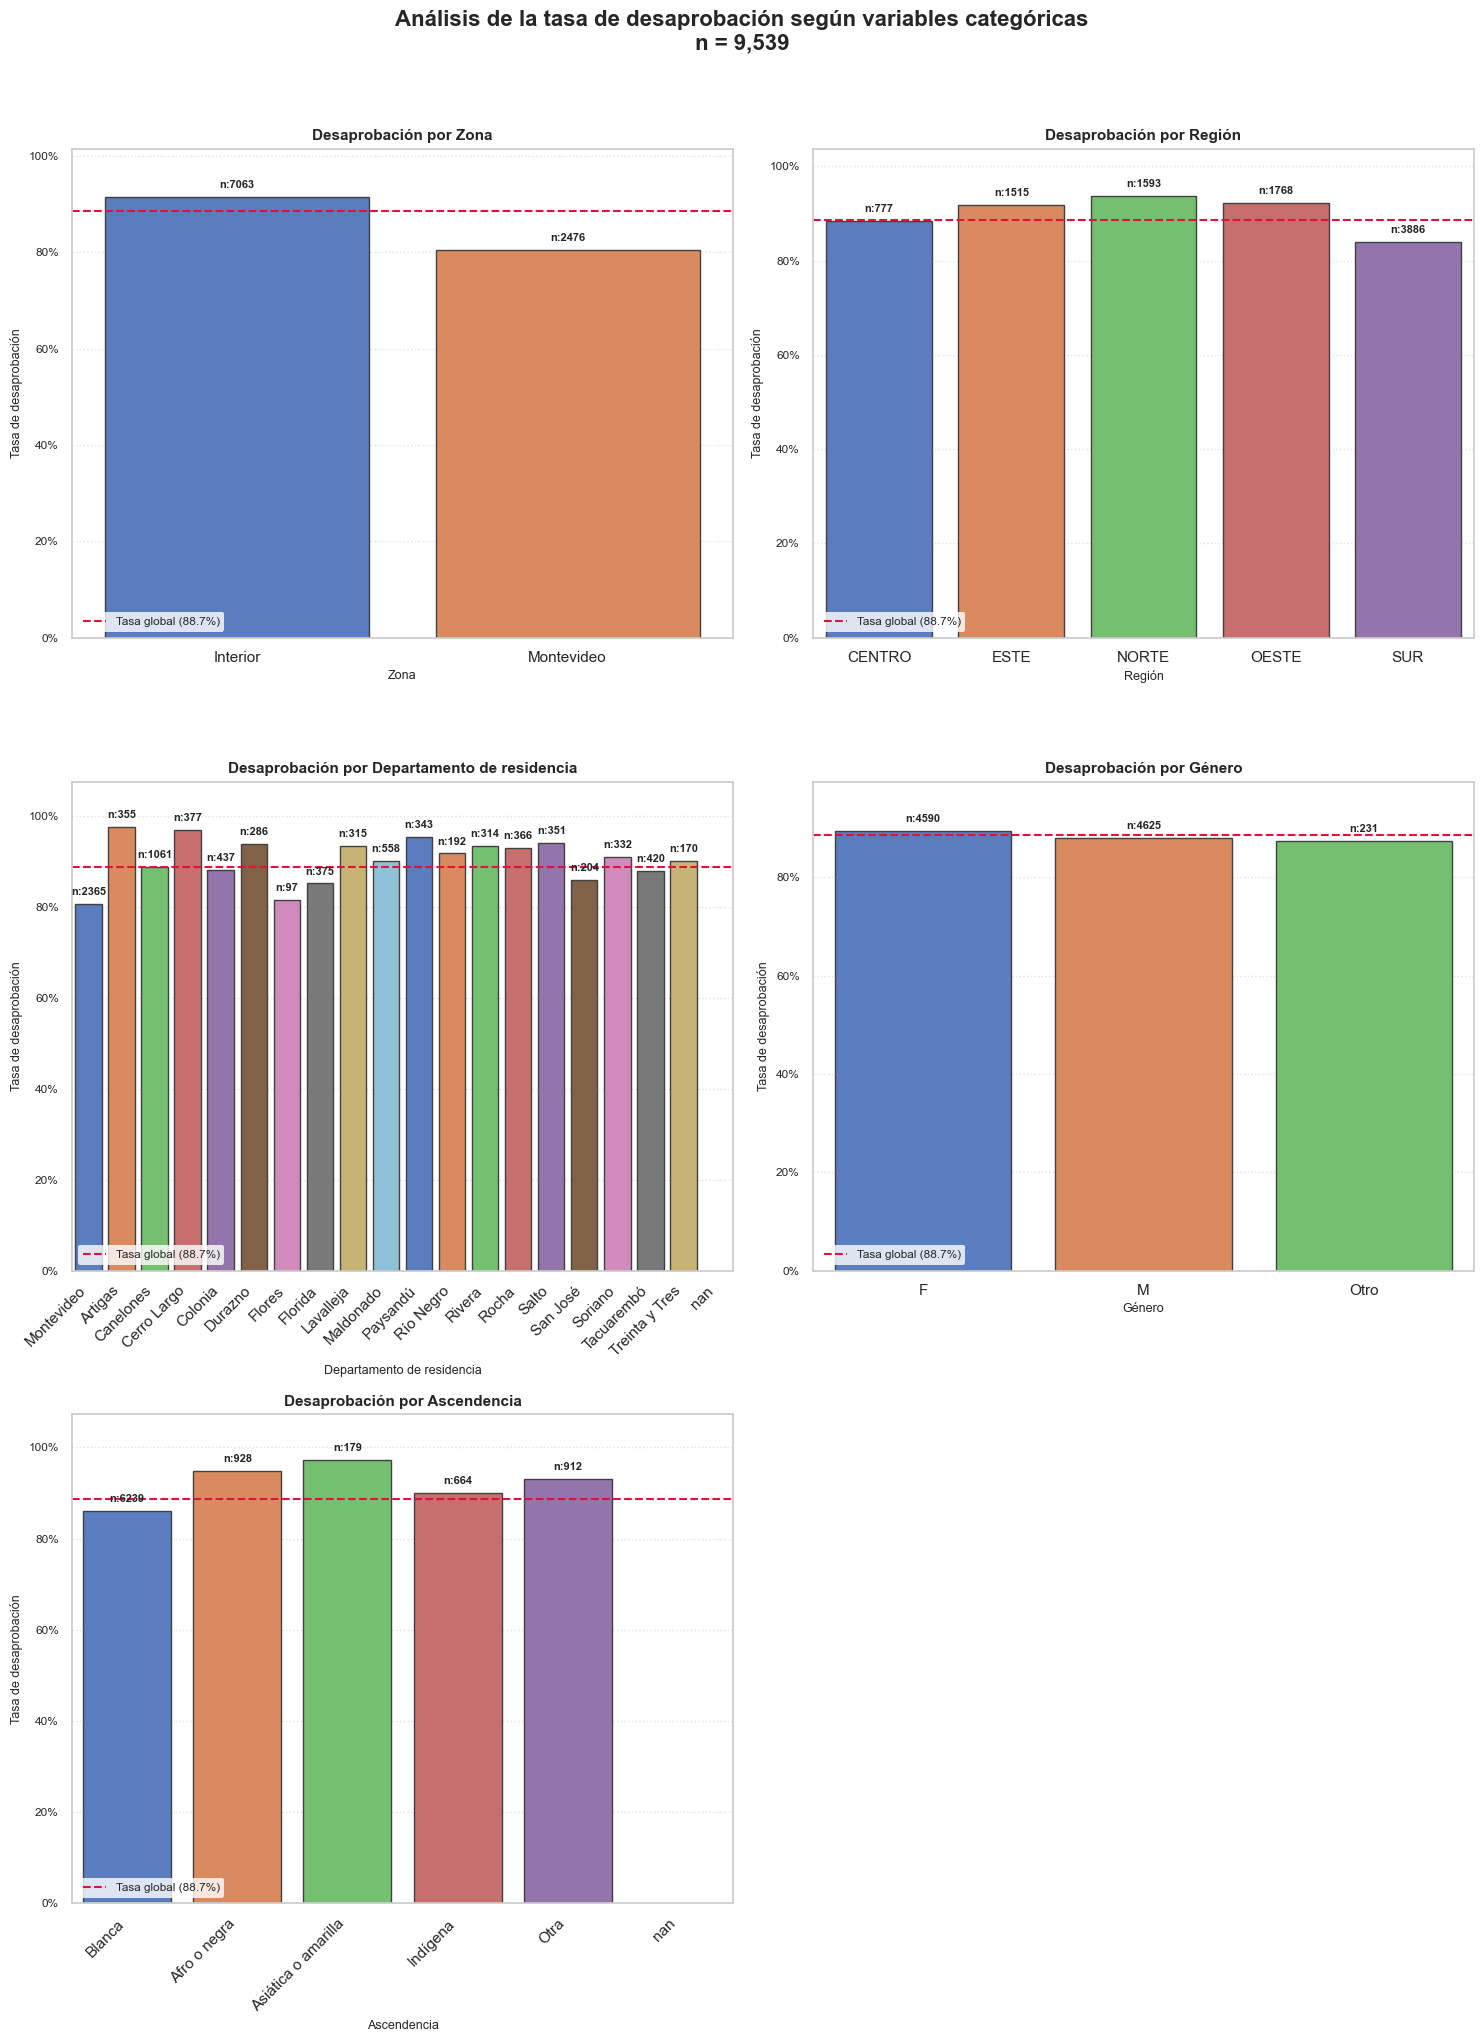

In [6]:
import matplotlib.ticker as mtick
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# Variables a graficar
# ==============================
variables_a_graficar = [
    'zona',
    'region',
    'departamento_residencia',
    'alumno_genero',
    'ascendencia'
]

# ==============================
# Diccionarios de etiquetas
# ==============================

mapa_ascendencia = {
    1: "Blanca",
    2: "Afro o negra",
    3: "Asiática o amarilla",
    4: "Indígena",
    5: "Otra"
}

mapa_departamentos = {
    1: "Montevideo",
    2: "Artigas",
    3: "Canelones",
    4: "Cerro Largo",
    5: "Colonia",
    6: "Durazno",
    7: "Flores",
    8: "Florida",
    9: "Lavalleja",
    10: "Maldonado",
    11: "Paysandú",
    12: "Río Negro",
    13: "Rivera",
    14: "Rocha",
    15: "Salto",
    16: "San José",
    17: "Soriano",
    18: "Tacuarembó",
    19: "Treinta y Tres"
}

# Títulos más amigables (opcional)
titulos = {
    'zona': 'Zona',
    'region': 'Región',
    'departamento_residencia': 'Departamento de residencia',
    'alumno_genero': 'Género',
    'ascendencia': 'Ascendencia'
}

# ==============================
# Tasa global
# ==============================

tasa_base = df_final_modelo['target'].mean()

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))
axes_flat = axes.flatten()

# ==============================
# Bucle de gráficos
# ==============================

for i, var in enumerate(variables_a_graficar):

    ax = axes_flat[i]
    ax.grid(False)

    data_grafico = (
        df_final_modelo
        .groupby(var)['target']
        .agg(
            tasa='mean',
            n='size'
        )
        .reset_index()
    )

    # Reemplazar etiquetas únicamente para el gráfico
    if var == 'ascendencia':
        data_grafico[var] = data_grafico[var].map(mapa_ascendencia)

    elif var == 'departamento_residencia':
        data_grafico[var] = data_grafico[var].map(mapa_departamentos)

    orden_categorias = data_grafico[var].tolist()

    sns.barplot(
        x=var,
        y='tasa',
        data=data_grafico,
        order=orden_categorias,
        hue=var,
        hue_order=orden_categorias,
        palette='muted',
        legend=False,
        edgecolor='#404040',
        ax=ax
    )

    # Línea de tasa global
    linea_base = ax.axhline(
        y=tasa_base,
        color='crimson',
        linestyle='--',
        linewidth=1.5
    )

    ax.legend(
        [linea_base],
        [f'Tasa global ({tasa_base:.1%})'],
        loc='lower left',
        fontsize=8.5,
        frameon=True,
        facecolor='white',
        edgecolor='none'
    )

    ax.set_title(
        f'Desaprobación por {titulos.get(var,var)}',
        fontsize=11,
        fontweight='bold'
    )

    ax.set_xlabel(titulos.get(var,var), fontsize=9)
    ax.set_ylabel('Tasa de desaprobación', fontsize=9)

    max_val = data_grafico['tasa'].max()
    ax.set_ylim(0, max(max_val + 0.10, tasa_base + 0.05))

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='y', labelsize=8.5)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

    # Rotar etiquetas si son largas
    if var in ['departamento_residencia', 'ascendencia']:
        ax.tick_params(axis='x', rotation=45)
        for tick in ax.get_xticklabels():
            tick.set_horizontalalignment('right')

    # Etiquetas con tamaño muestral
    for j, p in enumerate(ax.patches):

        if j >= len(data_grafico):
            break

        height = p.get_height()

        ax.annotate(
            f"n:{int(data_grafico.iloc[j]['n'])}",
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            xytext=(0,5),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold'
        )

# Ocultar ejes sobrantes
for j in range(len(variables_a_graficar), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    f'Análisis de la tasa de desaprobación según variables categóricas\nn = {len(df_final_modelo):,}',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

A partir de los gráficos, se observa que la tasa global de desaprobación en la prueba de Matemática es elevada (88,7%), aunque existen diferencias entre los distintos grupos analizados.

- Zona de residencia: los estudiantes del Interior presentan una tasa de desaprobación superior a la media y mayor que la observada en Montevideo, lo que sugiere una leve brecha territorial en el desempeño.

- Región: se aprecian diferencias moderadas entre regiones. Norte, Este y Oeste exhiben las tasas de desaprobación más altas, mientras que la región Sur presenta la menor proporción de estudiantes desaprobados, ubicándose por debajo de la tasa global.

- Departamento de residencia: existe heterogeneidad entre departamentos. Algunos, como Artigas, muestran tasas de desaprobación cercanas al 97%, mientras que Montevideo y Durazno presentan valores relativamente menores. Sin embargo, en varios departamentos el tamaño muestral es reducido, por lo que esas diferencias deben interpretarse con cautela.

- Género: las diferencias son prácticamente inexistentes. Mujeres y varones presentan tasas de desaprobación muy similares, cercanas a la media, mientras que la categoría "Otro" se ubica levemente por debajo, aunque con un número muy pequeño de casos (n=231).

- Ascendencia: se observan algunas diferencias. Los estudiantes que se identifican con ascendencia asiática o amarilla presentan la mayor tasa de desaprobación, seguidos por quienes reportan ascendencia afro o negra y otra. En contraste, quienes declaran ascendencia blanca muestran la menor tasa de desaprobación del grupo, situándose por debajo de la media global.

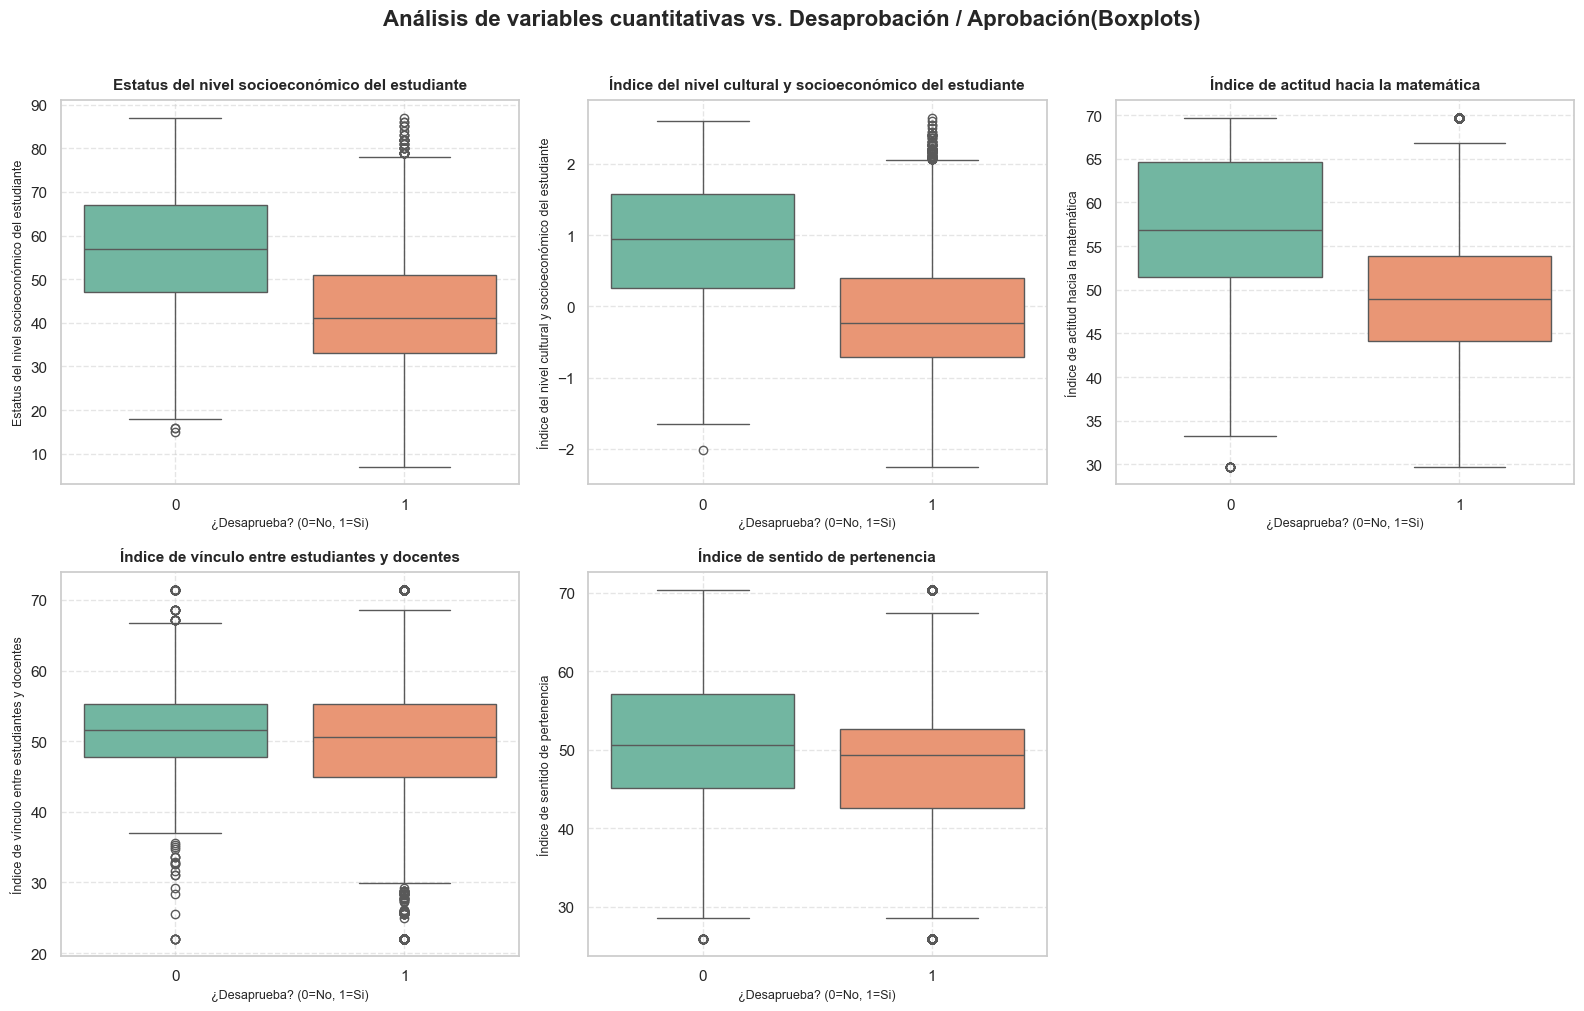

In [7]:
# 10. REALIZAR ANALISIS DE VARIABLES NUMERICAS (BOXPLOTS)

# Definimos las variables numéricas a analizar
variables_boxplot = [
    'idx_inse_alumno',
    'idx_esec_alumno',
    'idx_actitud_matematica',
    'idx_vinculo_estudiantes_docentes',
    'idx_sentido_pertenencia'
]

# Configuramos el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# Redefinimos el tamaño de la figura a un formato ideal (16 de base x 10 de alto)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

# Aplanamos la matriz de 2x3 para iterar linealmente del 0 al 5
axes_flat = axes.flat

# Mapeamos títulos
titulos = {
    'idx_inse_alumno': 'Estatus del nivel socioeconómico del estudiante',
    'idx_esec_alumno': 'Índice del nivel cultural y socioeconómico del estudiante',
    'idx_actitud_matematica': 'Índice de actitud hacia la matemática',
    'idx_vinculo_estudiantes_docentes': 'Índice de vínculo entre estudiantes y docentes',
    'idx_sentido_pertenencia': 'Índice de sentido de pertenencia'
}

# Iteramos para construir cada Boxplot
for i, var in enumerate(variables_boxplot):
    ax = axes_flat[i]

    sns.boxplot(
        x=df_final_modelo['target'],
        y=var,
        data=df_final_modelo,
        ax=ax,
        palette="Set2",
        hue=df_final_modelo['target'],
        legend=False
    )

    # Adaptamos títulos y etiquetas al ancho de las 2 columnas
    ax.set_title(
    f"{titulos.get(var, var)}",
    fontsize=11,
    fontweight='bold',
    pad=8)
    ax.set_xlabel("¿Desaprueba? (0=No, 1=Si)", fontsize=9)
    ax.set_ylabel(titulos.get(var, var), fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

# Apagamos cuadrantes vacíos
for j in range(len(variables_boxplot), len(axes_flat)):
    axes_flat[j].axis('off')

# Generamos título general, ajustamos layout y mostramos
plt.suptitle("Análisis de variables cuantitativas vs. Desaprobación / Aprobación(Boxplots)", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

A partir de los boxplots se observan diferencias claras entre los estudiantes que aprueban (0) y quienes desaprueban (1) la prueba de Matemática para algunos de los índices analizados.

- Estatus del nivel socioeconómico del estudiante: los estudiantes que aprueban presentan, en general, un nivel socioeconómico más alto. La mediana del índice es considerablemente superior en el grupo que aprueba, mientras que quienes desaprueban se concentran en valores más bajos. Esto sugiere una asociación negativa entre el nivel socioeconómico y la probabilidad de desaprobación.

- Índice del nivel cultural y socioeconómico del estudiante: se observa un patrón similar al anterior. Los estudiantes que aprueban presentan valores positivos y una mediana claramente superior, mientras que quienes desaprueban se concentran en valores inferiores. La diferencia entre ambos grupos es marcada, lo que indica que este índice podría ser un importante factor asociado al desempeño en Matemática.

- Índice de actitud hacia la matemática: los estudiantes que aprueban muestran una actitud más favorable hacia la asignatura, reflejada en una mediana sensiblemente mayor. Aunque existe cierto solapamiento entre ambos grupos, la distribución evidencia que una actitud más positiva hacia la Matemática se asocia con una menor probabilidad de desaprobación.

- Índice de vínculo entre estudiantes y docentes: las distribuciones de ambos grupos son muy similares, con medianas prácticamente iguales y una fuerte superposición de los rangos intercuartílicos. Esto sugiere que, de manera aislada, este indicador presenta una capacidad limitada para diferenciar entre estudiantes que aprueban y desaprueban.

- Índice de sentido de pertenencia: también se observan diferencias reducidas entre ambos grupos. Los estudiantes que aprueban presentan una mediana ligeramente superior, aunque la superposición entre las distribuciones es considerable, por lo que el sentido de pertenencia parece tener una asociación más débil con el resultado de la prueba.

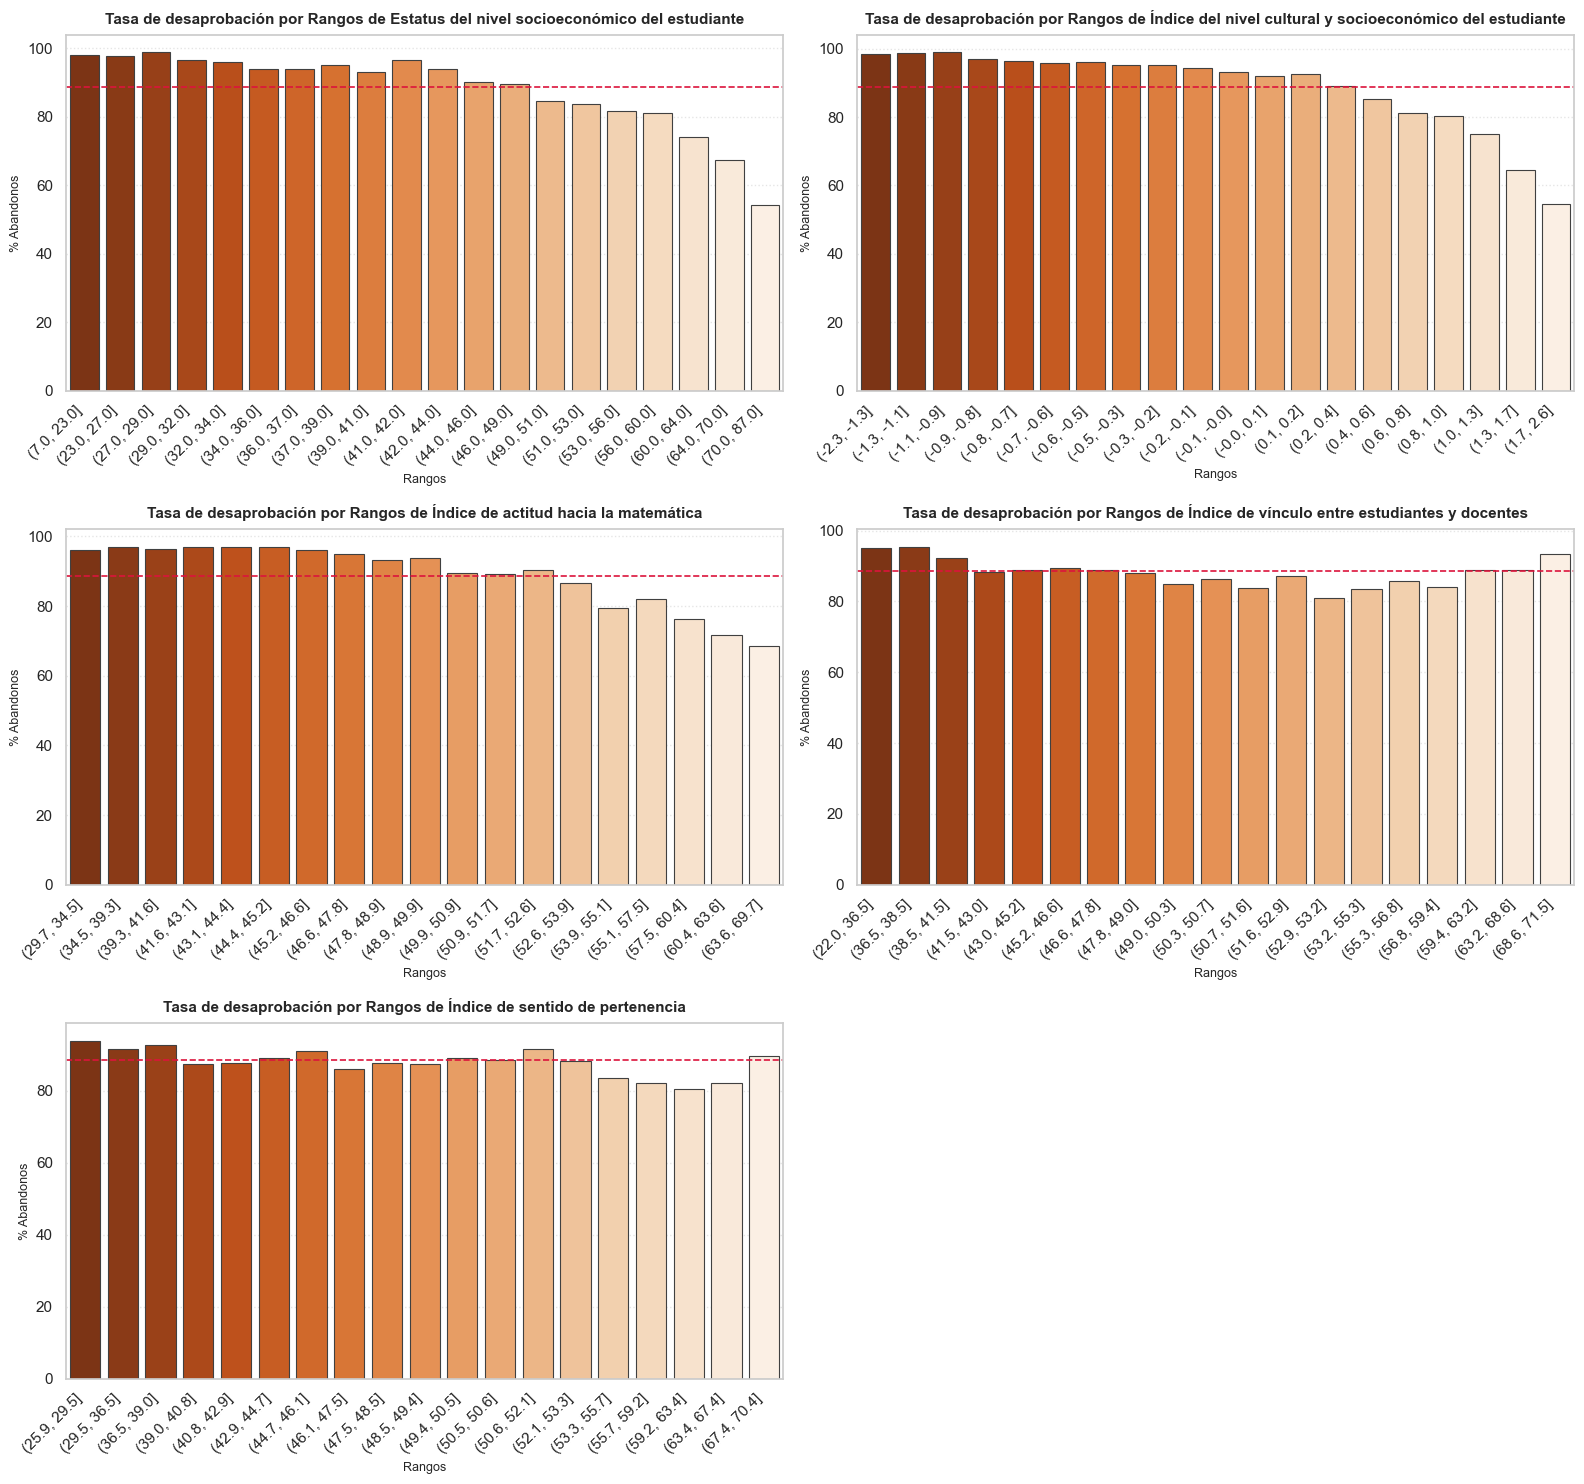

In [9]:
# BARPLOTS DE TASA DE DESAPROBACION POR RANGOS DE VARIABLES NUMERICAS

import math

# Hacemos lo mismo pero para las variables numericas, pero a estas las tendremos que dividir en rangos para los graficos de barras. 

n_cols = 2
# Calculamos las filas necesarias de forma dinámica
n_rows = math.ceil(len(variables_boxplot) / n_cols) 

# Creamos la copia de trabajo y pasamos el target a porcentaje directo (0 a 100%)
df_plot = df_final_modelo.copy()
df_plot['Desaprueba_porcentaje'] = df_plot['target'].map({1: 100, 0: 0})

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

# Aplanamos el array de ejes para poder iterar en un solo bucle limpio (aplasta una matriz 2D en 1D)
axes = axes.flatten()

# ==================================================================================================
# BUCLE EN MATRIZ DE SUBPLOTS
# ==================================================================================================
for i, var in enumerate(variables_boxplot):
    ax = axes[i]
    col_intervalo = f'{var}_Rango'
    
    # 1. Creamos los rangos con qcut
    intervalos = pd.qcut(df_plot[var], q=20, duplicates='drop')
    
    # 2. Forzamos estrictamente el formato a 1 decimal (ej: "(25.8, 29.5]")
    df_plot[col_intervalo] = intervalos.apply(
        lambda x: f"({x.left:.1f}, {x.right:.1f}]" if pd.notna(x) else x
    )

    data_tasa_num = (
        df_plot.groupby(col_intervalo, observed=True)['Desaprueba_porcentaje']
        .mean()
        # sort_index() funciona mal si los rangos son texto y no categorías, 
        # pero al venir de qcut, el groupby ya respeta el orden original de los intervalos
        .reset_index()
    )

    # Ya no necesitamos hacer el .astype(str) porque el lambda de arriba ya los convirtió a texto
    
    # Dibujamos el barplot en el eje correspondiente
    sns.barplot(
        x=col_intervalo, 
        y='Desaprueba_porcentaje', 
        data=data_tasa_num, 
        palette='Oranges_r',
        hue=col_intervalo,
        legend=False,
        ax=ax,
        edgecolor='#404040', 
        linewidth=0.8
    )

    tasa_base = df_plot['Desaprueba_porcentaje'].mean()  
    
    # Añadimos la línea roja con la tasa base del modelo
    ax.axhline(
        y=tasa_base, 
        color='crimson', 
        linestyle='--', 
        linewidth=1.2, 
        label=f'Base Global ({tasa_base:.2f}%)' if i == 0 else ""
    )

    ax.set_title(f"Tasa de desaprobación por Rangos de {titulos.get(var, var)}", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Rangos', fontsize=9) 
    ax.set_ylabel('% Abandonos', fontsize=9)
    ax.set_ylim(0, max(data_tasa_num['Desaprueba_porcentaje'].max() + 5, 25))
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

# Eliminamos los subplots sobrantes si el número de variables es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

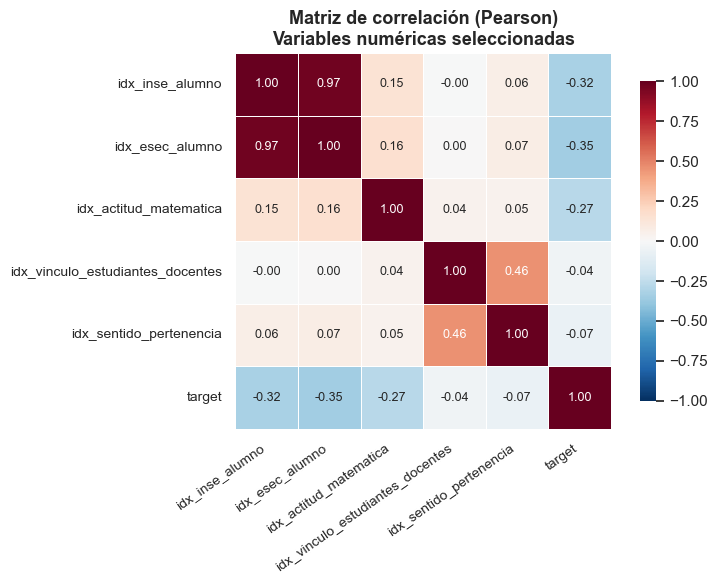

/var/folders/0m/rbf8dr3s1_g2h0t7g9scdbsr0000gn/T/ipykernel_42418/3222434985.py:81: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


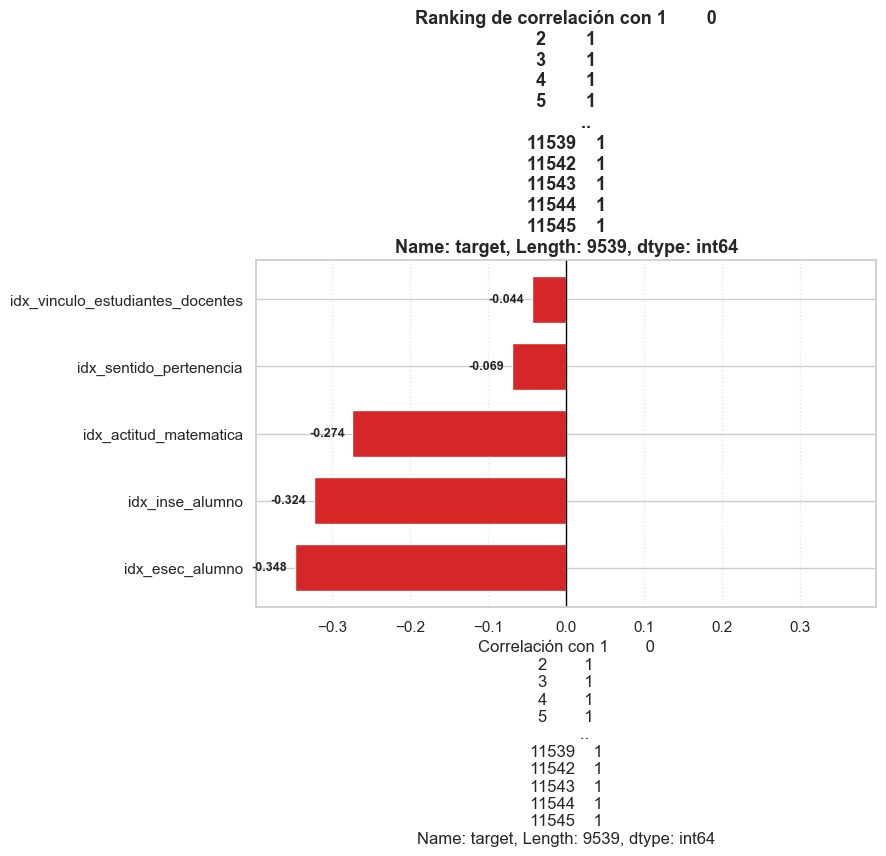

In [10]:
# 13. MATRIZ DE CORRELACIÓN (SOLO VARIABLES DE variables_boxplot + target)

# Seleccionar únicamente las variables de interés
df_eda_corr = df_final_modelo[variables_boxplot + ['target']].copy()

# Matriz de correlación
corr_eda = df_eda_corr.corr(numeric_only=True)

# Reordenar para dejar el target al final
cols_ordenadas = [c for c in corr_eda.columns if c != 'target'] + ['target']
corr_eda = corr_eda.loc[cols_ordenadas, cols_ordenadas]

# -------------------- Heatmap --------------------
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_eda,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.85},
    annot_kws={"size": 9}
)

plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title(
    'Matriz de correlación (Pearson)\nVariables numéricas seleccionadas',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


# -------------------- Ranking Tornado --------------------

corr_target = corr_eda['target'].drop('target')

ranking_pos = corr_target[corr_target >= 0].sort_values(ascending=False)
ranking_neg = corr_target[corr_target < 0].sort_values(ascending=False)

ranking = pd.concat([ranking_pos, ranking_neg])

fig, ax = plt.subplots(figsize=(8, 4.5))

colores = ['#2ca02c' if v >= 0 else '#d62728' for v in ranking]

ax.barh(ranking.index, ranking.values, color=colores, height=0.7)
ax.axvline(0, color='black', linewidth=1)

ax.invert_yaxis()
ax.set_xlabel(f'Correlación con {df_final_modelo['target']}')
ax.set_title(
    f'Ranking de correlación con {df_final_modelo['target']}',
    fontsize=13,
    fontweight='bold'
)

for i, v in enumerate(ranking.values):
    ax.text(
        v + (0.01 if v >= 0 else -0.01),
        i,
        f'{v:+.3f}',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=9,
        fontweight='semibold'
    )

lim = max(abs(ranking.min()), abs(ranking.max())) + 0.05
ax.set_xlim(-lim, lim)
ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Análisis de correlaciones con la tasa de desaprobación (target)

* Los factores socioeconómicos y educativos (idx_inse_alumno e idx_esec_alumno) son los que más se asocian (aunque de forma moderada) con la desaprobación: a mejores índices, menor tasa de desaprobación.

* La actitud hacia matemáticas tiene cierta influencia, pero es más débil que los factores estructurales.

* El vínculo con docentes y el sentido de pertenencia tienen una correlación casi nula con la desaprobación, lo que sugiere que, en este contexto, no son factores determinantes para explicar el rendimiento en términos de aprobación/desaprobación.

* No hay correlaciones fuertes (todas están por debajo de 0.4 en valor absoluto), lo que indica que la desaprobación es un fenómeno multifactorial y que estas variables explican solo una parte de su variabilidad.

Durante el análisis exploratorio (EDA), se identificó la presencia de valores atípicos (e.g., códigos 98 y 99) en variables sociodemográficas como la Ascendencia. Dado que el diccionario de datos oficial del INEEd solo categoriza respuestas del 1 al 5, se infirió que estos códigos corresponden a marcas de sistema para 'No sabe/No contesta'. En consecuencia, fueron transformados a nulos (NaN) para permitir un manejo correcto en el Pipeline de imputación y no distorsionar la evaluación de equidad algorítmica.  

Para el INEEd cada nivel describe qué es capaz de hacer el estudiante en términos de complejidad cognitiva, basándose en los programas oficiales de ANEP:
- B1 y Nivel 1: El estudiante solo puede resolver tareas matemáticas muy elementales, rutinarias y con información explícita.
- Nivel 2: Logra resolver problemas simples de un solo paso o extraer datos directos de tablas y gráficos.
- Nivel 3: Es considerado habitualmente el nivel de transición o el umbral de competencia básica esperada. El estudiante puede resolver problemas que requieren relacionar algunos datos o hacer cálculos secuenciales sencillos.
- Niveles 4 y 5: El estudiante demuestra una consolidación profunda. Es capaz de modelizar matemáticamente situaciones de la vida real, resolver problemas no rutinarios, interpretar conceptos algebraicos y argumentar sus respuestas.

La binarización aplicada responde a una mirada de política pública orientada a la excelencia y consolidación real de los aprendizajes, donde el "rendimiento satisfactorio" no es solo "saber lo mínimo indispensable" (Nivel 3), sino tener la robustez cognitiva (Niveles 4 y 5) necesaria para continuar trayectorias educativas complejas sin rezago.

In [ ]:
# =====================================================================
# PASO 3: Preparación previa y split
# =====================================================================

# Split estratificado
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42, stratify=y
)

# Definición explicita de las columnas categóricas basadas en el diccionario

 # --- Variables Demográficas y Geográficas ---
columnas_categoricas = [
    "zona",
    "region",
    "departamento_residencia",
    "categoria_centro",
    "categoria_grupo",
    "alumno_genero",
    "ascendencia",
    "pais_nacimiento",
    "edad"
]


# Las columnas numéricas serán todas las demás de X
columnas_numericas = [col for col in X.columns if col not in columnas_categoricas]

# Por precaución extra, forzamos a numérico (convierte cualquier problema a NaN para que el imputer trabaje)
X_train = X_train.copy()
X_test = X_test.copy()
X_train[columnas_numericas] = X_train[columnas_numericas].apply(pd.to_numeric, errors='coerce')
X_test[columnas_numericas] = X_test[columnas_numericas].apply(pd.to_numeric, errors='coerce')

In [ ]:
# =====================================================================
# PASO 4: Construcción del Preprocesador
# =====================================================================

# Imputación KNN para numéricas y escalado
transformador_num = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ("scaler", StandardScaler()),
])

# Imputación por moda y OneHot para categóricas
transformador_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocesador = ColumnTransformer(transformers=[
    ("num", transformador_num, columnas_numericas),
    ("cat", transformador_cat, columnas_categoricas),
])

In [ ]:
# =====================================================================
# PASO 5: Generación de Modelos, GridSearchCV y Ajuste
# =====================================================================

# Definir modelos a analizar
modelos = {
    "Regresion_Logistica": LogisticRegression(random_state=42, class_weight="balanced", max_iter=3000, solver="saga"),
    "Random_Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    # En XGBoost usamos scale_pos_weight en lugar de class_weight
    "XGBoost": XGBClassifier(random_state=42, eval_metric="auc", scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train))
}

# Definir grillas de hiperparámetros más compactas
param_grids = {
    "Regresion_Logistica": {
        "clasificador__C": [0.1, 1.0, 10.0],
        "clasificador__l1_ratio": [0.0, 0.5, 1.0]
    },
    "Random_Forest": {
        "clasificador__n_estimators": [100, 200],
        "clasificador__max_depth": [10, 20, None],
        "clasificador__min_samples_split": [2, 5]
    },
    "XGBoost": {
        "clasificador__n_estimators": [100, 200],
        "clasificador__max_depth": [3, 5, 7],
        "clasificador__learning_rate": [0.01, 0.1]
    }
}

cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_grid = {}

# Entrenar todos los modelos
for nombre_modelo, modelo in modelos.items():
    print(f"\nEntrenando {nombre_modelo}...")
    
    pipeline_completo = Pipeline(steps=[
        ("preprocesamiento", preprocesador),
        ("clasificador", modelo)
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline_completo,
        param_grid=param_grids[nombre_modelo],
        cv=cv_estrategia,
        scoring="roc_auc",
        n_jobs=7,
        error_score="raise"
    )
    
    # Manejo dinámico de pesos muestrales (w_train)
    # Ajuste con pesos de encuesta para todos los algoritmos que lo soportan
    fit_params = {"clasificador__sample_weight": w_train}
    grid_search.fit(X_train, y_train, **fit_params)
    
    resultados_grid[nombre_modelo] = grid_search

In [ ]:
# =====================================================================
# PASO 6: Definición del modelo ganador
# =====================================================================

mejor_nombre = None
mejor_score = 0
mejor_grid = None

print("\n--- Comparación de Modelos (ROC-AUC en Validación Cruzada) ---")
for nombre, grid in resultados_grid.items():
    score_cv = grid.best_score_
    print(f"{nombre}: {score_cv:.4f}")
    if score_cv > mejor_score:
        mejor_score = score_cv
        mejor_nombre = nombre
        mejor_grid = grid

print(f"\nEl modelo ganador es: {mejor_nombre} con ROC-AUC de {mejor_score:.4f}")
mejor_modelo = mejor_grid.best_estimator_

In [ ]:
# =====================================================================
# PASO 7: Análisis de Feature Importance
# =====================================================================

print("\n--- Feature Importance del Mejor Modelo ---")
try:
    # Extraer el clasificador y los nombres de las features del preprocesador
    clasificador_entrenado = mejor_modelo.named_steps["clasificador"]
    
    # Obtener nombres de columnas categóricas luego del OneHot
    nombres_cat = mejor_modelo.named_steps["preprocesamiento"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(columnas_categoricas)
    todas_las_features = columnas_numericas + list(nombres_cat)
    
    if hasattr(clasificador_entrenado, "feature_importances_"):
        importancias = clasificador_entrenado.feature_importances_
    elif hasattr(clasificador_entrenado, "coef_"):
        importancias = np.abs(clasificador_entrenado.coef_[0])
        
    df_importances = pd.DataFrame({"Feature": todas_las_features, "Importancia": importancias})
    df_importances = df_importances.sort_values(by="Importancia", ascending=False).head(10)
    print(df_importances)
except Exception as e:
    print("No se pudo calcular la importancia de variables directamente. (Revisar compatibilidad del modelo).")

In [ ]:
# =====================================================================
# PASO 8: Resultados y evaluación en Test
# =====================================================================

print("\n--- Evaluación en Test (Ponderada) ---")
print("Mejores hiperparámetros encontrados:", mejor_grid.best_params_)

y_pred_proba = mejor_modelo.predict_proba(X_test)[:, 1]
score_test = roc_auc_score(y_test, y_pred_proba, sample_weight=w_test)
print(f"ROC-AUC en conjunto de Test (ponderado): {score_test:.4f}")

# Generar la predicción estándar de clases
y_pred = mejor_modelo.predict(X_test)

# Calcular la matriz de confusión PONDERADA
cm_ponderada = confusion_matrix(y_test, y_pred, sample_weight=w_test)

# Configurar Numpy para evitar notación científica en el print de la consola
np.set_printoptions(suppress=True)
print("Matriz de Confusión Ponderada (Poblacional):")
print(cm_ponderada)

# Visualizarla de forma gráfica evitando notación científica
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ponderada, 
    display_labels=["Insatisfactorio", "Satisfactorio"]
)

# El parámetro values_format=',.0f' quita la notación científica y agrega separador de miles
disp.plot(cmap=plt.cm.Blues, values_format=',.0f')
plt.title(f"Matriz de Confusión Ponderada - {mejor_nombre}")
plt.show()

In [ ]:
# =====================================================================
# PASO 9: Auditoría de Equidad (Fairness)
# =====================================================================

print("\n" + "="*60)
print("--- Auditoría de Equidad (Fairness) ---")
print("="*60)

variables_auditar = ["ascendencia", "alumno_genero", "zona", "categoria_centro"]

# Diccionario actualizado con el orden específico solicitado
metricas_a_evaluar = {
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "F1-score": f1_score,
    "ROC AUC": roc_auc_score
}

for var in variables_auditar:
    # Se extrae la variable sensible del conjunto de test original
    variable_sensible_test = X_test[var]
    
    metric_frame = MetricFrame(
        metrics=metricas_a_evaluar,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=variable_sensible_test,
        sample_params={
            "Accuracy": {"sample_weight": w_test},
            "Precision": {"sample_weight": w_test},
            "Recall": {"sample_weight": w_test},
            "F1-score": {"sample_weight": w_test},
            "ROC AUC": {"sample_weight": w_test},
        },
    )
    
    # Obtener el dataframe de resultados
    df_resultados = metric_frame.by_group
    
    # 1. SALIDA EN CONSOLA
    print(f"\n>> Resultados poblacionales por subgrupo de: {var.upper()}")
    print("-" * 60)
    # Formatear la tabla para mostrar exactamente 3 decimales
    print(df_resultados.to_string(float_format="{:.3f}".format))
    print("-" * 60)
    
    # 2. VISUALIZACIÓN GRÁFICA
    # Genera un gráfico de barras agrupadas para comparar fácilmente
    ax = df_resultados.plot(
        kind='bar', 
        figsize=(10, 5), 
        colormap='viridis', # Una paleta de colores elegante y accesible
        edgecolor='black',
        alpha=0.85
    )
    
    plt.title(f"Métricas de Equidad por subgrupo: {var.capitalize()}", fontsize=14, pad=15)
    plt.ylabel("Valor de la Métrica", fontsize=12)
    plt.xlabel(var.capitalize(), fontsize=12)
    plt.xticks(rotation=0) # Mantener los nombres de las etiquetas horizontales
    
    # Mover la leyenda fuera del gráfico para que no tape las barras
    plt.legend(title="Métricas", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Añadir el valor numérico encima de cada barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
        
    plt.tight_layout()
    plt.show()

In [ ]:
# =====================================================================
# PASO 10: Análisis de Costos y Threshold Moving
# =====================================================================

print("\n" + "="*60)
print("--- Análisis de Costos y Threshold Moving ---")
print("="*60)

# 1. Costos fundamentados en datos de ANEP
costo_fp = 8700  # Costo anual de un alumno repitiendo (Secundaria)
costo_fn = 87040   # Estimación de tutorías (aprox. 10% del costo anual)
costo_vp = 0
costo_vn = 0

umbrales = np.linspace(0.0, 1.0, 100)
costos_totales_train = []

# 2. Búsqueda del umbral en TRAIN mediante Validación Cruzada Out-Of-Fold
# Prevenimos el Data Leakage al no tocar el X_test para esta decisión
fit_params = {"clasificador__sample_weight": w_train}

y_pred_proba_train = cross_val_predict(
    mejor_modelo, 
    X_train, 
    y_train, 
    cv=5, 
    method="predict_proba", 
    params=fit_params,
    n_jobs=-1
)[:, 1]

# 3. Iterar sobre posibles umbrales en TRAIN para encontrar el costo mínimo
for umbral in umbrales:
    y_pred_umbral_train = (y_pred_proba_train >= umbral).astype(int)
    cm_train = confusion_matrix(y_train, y_pred_umbral_train, sample_weight=w_train)
    
    if cm_train.shape == (2, 2):
        vn, fp, fn, vp = cm_train.ravel()
    else:
        vn, fp, fn, vp = 0, 0, 0, 0
        
    costo_total = (fp * costo_fp) + (fn * costo_fn) + (vp * costo_vp) + (vn * costo_vn)
    costos_totales_train.append(costo_total)

# 4. Identificar el umbral óptimo en TRAIN
indice_optimo = np.argmin(costos_totales_train)
umbral_optimo = umbrales[indice_optimo]

print(f"Umbral Óptimo encontrado en TRAIN (Out-Of-Fold): {umbral_optimo:.2f}")

# =====================================================================
# PASO 11: Evaluación final en TEST (auditoría real del negocio)
# =====================================================================

y_pred_proba_test = mejor_modelo.predict_proba(X_test)[:, 1]

# Costo con el umbral default (0.50) evaluado en TEST
y_pred_default_test = (y_pred_proba_test >= 0.50).astype(int)
cm_default_test = confusion_matrix(y_test, y_pred_default_test, sample_weight=w_test)
vn_def, fp_def, fn_def, vp_def = cm_default_test.ravel()
costo_default_test = (fp_def * costo_fp) + (fn_def * costo_fn)

# Costo con el umbral óptimo (calculado en Train) evaluado en TEST
y_pred_optimo_test = (y_pred_proba_test >= umbral_optimo).astype(int)
cm_optimo_test = confusion_matrix(y_test, y_pred_optimo_test, sample_weight=w_test)
vn_opt, fp_opt, fn_opt, vp_opt = cm_optimo_test.ravel()
costo_optimo_test = (fp_opt * costo_fp) + (fn_opt * costo_fn)

print("-" * 60)
print(f"Costo operativo en TEST (Umbral 0.50): ${costo_default_test:,.0f} UYU")
print(f"Costo operativo en TEST (Umbral {umbral_optimo:.2f}): ${costo_optimo_test:,.0f} UYU")
print(f"Ahorro económico validado en TEST: ${costo_default_test - costo_optimo_test:,.0f} UYU")

# =====================================================================
# PASO 12: Anexo Analítico - Curva Precisión/Recall vs Umbral
# =====================================================================

print("\nGenerando gráfica de Precisión y Recall vs Umbral...")

# 1. Calcular precisión, recall y umbrales usando la validación cruzada y pesos
precisions, recalls, thresholds_pr = precision_recall_curve(
    y_train, 
    y_pred_proba_train, 
    sample_weight=w_train
)

# 2. Configurar la gráfica
plt.figure(figsize=(10, 6))

# Nota: thresholds_pr tiene un elemento menos que precisions y recalls, 
# por lo que graficamos hasta [:-1]
plt.plot(thresholds_pr, precisions[:-1], label='Precisión', color='royalblue', linewidth=2.5)
plt.plot(thresholds_pr, recalls[:-1], label='Recall (Sensibilidad)', color='darkorange', linewidth=2.5)

# 3. Marcar los umbrales de interés calculados en el paso anterior
plt.axvline(x=umbral_optimo, color='green', linestyle='--', linewidth=2, 
            label=f'Umbral Óptimo Costos ({umbral_optimo:.2f})')
plt.axvline(x=0.50, color='gray', linestyle=':', linewidth=2, 
            label='Umbral Default (0.50)')

# 4. Estética y etiquetas
plt.title('Compensación entre Precisión y Recall según el Umbral de Decisión', fontsize=14, pad=15)
plt.xlabel('Umbral de Decisión (Probabilidad mínima para predecir "Satisfactorio")', fontsize=12)
plt.ylabel('Valor de la Métrica', fontsize=12)

# Configurar límites y cuadrícula
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, alpha=0.4, linestyle='--')
plt.legend(loc='lower left', fontsize=11)

plt.tight_layout()
plt.show()

#### Información relevante para la estimación de costos:

1. Según información publicada por el diario EL PAIS en https://www.elpais.com.uy/informacion/educacion/cuanto-gasta-el-estado-en-promedio-por-cada-estudiante-que-asiste-a-la-educacion-publica el costo anual promedio por alumno en educación secundaria para el año 2024 fue de $ 87.040 (pesos uruguayos).

2. Para determinar el costo por alumno se toma en cuenta el gasto asociado a la remuneración por docencia directa, docencia indirecta y funciones de gestión, sin considerar los aportes patronales a la Seguridad Social. Por esta forma de cálculo, el tamaño de la matrícula en cada centro es un factor determinante, ya que en los más grandes se aplican economías de escala.  

3. Concentración del gasto: Según los informes financieros de ANEP, la inmensa mayoría del costo por estudiante (cerca del 90%) se explica por las remuneraciones docentes (horas de docencia directa e indirecta). Por lo tanto, el costo marginal de cualquier intervención está atado casi exclusivamente a la carga horaria adicional.

4. Carga horaria base: Un estudiante de Educación Media Básica (Ciclo Básico) cursa un promedio de 30 a 32 horas semanales de clase.

5. Carga horaria de la intervención: Los programas de apoyo tradicional (como tutorías de fortalecimiento en matemática o acompañamiento pedagógico) suelen estructurarse en bloques de 2 a 3 horas semanales extraoficiales.

6. Si a una base de ~30 horas se suma un módulo de apoyo de ~3 horas semanales, se está incrementando el esfuerzo docente en un 10%. En consecuencia, asumimos que el costo para el Estado por aplicar un programa de apoyo al estudiante se incrementa proporcionalmente en un 10% (pasando de requerir $87.000 anuales a requerir aproximadamente $95.700).

#### Escenario de estimación de costos:

Para realizar el análisis de Treshold Moving se planteo el siguiente escenario:

- Falso Positivo (FP): El modelo predice que el alumno tiene un desempeño "Satisfactorio", no se hace nada, pero el alumno fracasa y repite. El costo económico para el Estado es tener que financiar un año lectivo completo nuevamente. Según los datos oficiales y los informes de Análisis de Costo por Estudiante antes mencionados, la inversión anual promedio por alumno en Educación Secundaria es de $87.040 pesos uruguayos.

- Falso Negativo (FN): El modelo predice "Insatisfactorio", el centro asigna recursos para apoyo (tutorías, horas de acompañamiento), pero el alumno no lo necesitaba. ANEP destina aproximadamente el 88,6% de su presupuesto a remuneraciones. Si estimamos que un módulo de tutoría implica un 10% del esfuerzo horario anual de un alumno, el costo del error es de aproximadamente $8.700 pesos uruguayos.